# Predict LTV

- We will use 6 months of customers data to predict their 6-month LTV
- In practice, a company would use the first few months to understand customers' behaviour and then predict how much revenue they would bring in the following months
- We will use data from the entire year of 2014
- We use customers behaviours in the first 6 months (Jan - Jun) to predict their LTV/Revenue in the next 6 months

In [45]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# import built-in package
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from fuzzy import rfm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Importing data

In [2]:
order_df = pd.read_csv("../data/processed_data/orders.csv")
item_df = pd.read_csv("../data/processed_data/order_items.csv")

In [3]:
order_df = order_df[["order_id","user_id","items_purchased","price_usd","cogs_usd"]]
order_df = order_df.rename(columns={"items_purchased":"items_in_order","price_usd":"order_price_usd","cogs_usd":"order_cogs_usd"})

merged_df = item_df.merge(order_df,on="order_id",how="left")
ltv_df = merged_df[(merged_df['date'] >= "2014-01-01") & (merged_df['date'] <= "2014-12-31")]
feature_df = ltv_df[(merged_df['date'] >= "2014-01-01") & (ltv_df['date'] <= "2014-06-30")]

/var/folders/rc/s2_95tz949s0vjwhs4qv05_w0000gn/T/ipykernel_98350/835536032.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  feature_df = ltv_df[(merged_df['date'] >= "2014-01-01") & (ltv_df['date'] <= "2014-06-30")]


# Calculate RMF

Calculate the RMF of the customers in the first 6 months of 2014 to predict their LTV/Profit

In [4]:
score_df = pd.DataFrame(feature_df["user_id"].unique())
score_df.columns = ["user_id"]
score_df = score_df.sort_values(by="user_id",ignore_index=True)
score_df

,user_id
0,117878
1,118185
2,118933
3,119151
4,119790
...,...
6796,234941
6797,234943
6798,234961
6799,234967


## Recency

When calculating recency, we will make the first day after the cut-off, which is 01/07/2014, the "present day"

In [5]:
# Present day is 01/07/2013
present_day = pd.to_datetime("2014-07-01")
recency_df = rfm.calculate_recency(feature_df,present_day)

# Add recency to score_df
score_df = score_df.merge(recency_df[["user_id","recency"]],on="user_id")
score_df

,user_id,recency
0,117878,174
1,118185,177
2,118933,180
3,119151,176
4,119790,174
...,...,...
6796,234941,1
6797,234943,1
6798,234961,1
6799,234967,1


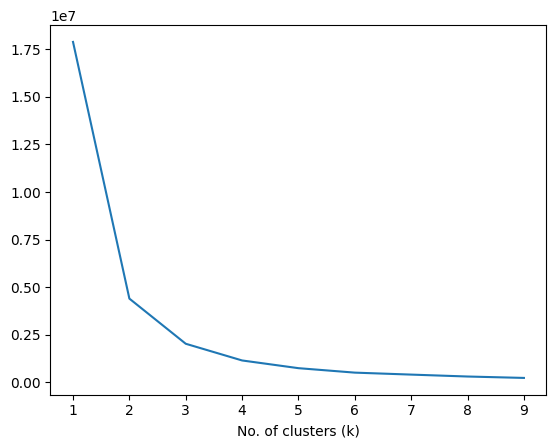

In [6]:
rfm.find_k(score_df,"recency")

- k can either be 3 or 4
- We will proceed with k = 4

In [7]:
kmeans = KMeans(n_clusters=4).fit(score_df[["recency"]])
score_df["recency_cluster"] = kmeans.predict(score_df[["recency"]])
score_df = rfm.reorder_cluster(score_df,"recency_cluster","recency",False)
score_df.groupby(by="recency_cluster")["recency"].describe()

,count,mean,std,min,25%,50%,75%,max
recency_cluster,,,,,,,,
0,1689.0,154.084665,14.564876,131.0,141.0,153.0,166.0,181.0
1,1532.0,107.896214,12.729782,86.0,97.0,108.0,119.0,130.0
2,1764.0,64.082766,12.031390,44.0,54.0,63.0,75.0,85.0
3,1816.0,22.458150,12.581827,1.0,12.0,22.0,33.0,43.0


## Frequency

In [8]:
# Calculate frequency
freq_df = rfm.calculate_frequency(feature_df)
# Add frequency to score_df
score_df = score_df.merge(freq_df[["user_id","frequency"]],on="user_id")
score_df

,user_id,recency,recency_cluster,frequency
0,117878,174,0,1
1,118185,177,0,1
2,118933,180,0,1
3,119151,176,0,1
4,119790,174,0,1
...,...,...,...,...
6796,234941,1,3,2
6797,234943,1,3,2
6798,234961,1,3,1
6799,234967,1,3,1


/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(esti

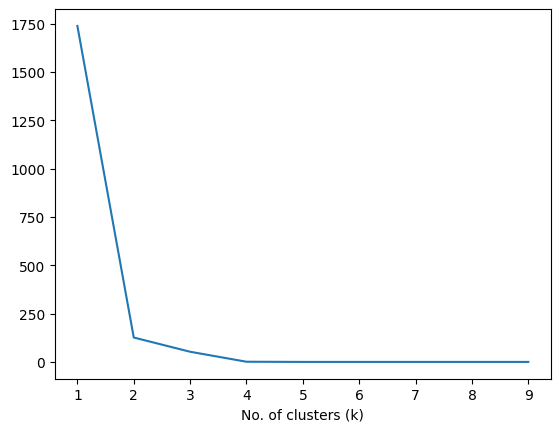

In [9]:
rfm.find_k(score_df,"frequency")

- We proceed with k = 2

In [10]:
kmeans = KMeans(n_clusters=2).fit(score_df[["frequency"]])
score_df["frequency_cluster"] = kmeans.predict(score_df[["frequency"]])
score_df = rfm.reorder_cluster(score_df,"frequency_cluster","frequency",False)
score_df.groupby(by="frequency_cluster")["frequency"].describe()

,count,mean,std,min,25%,50%,75%,max
frequency_cluster,,,,,,,,
0,2200.0,2.040909,0.239674,2.0,2.0,2.0,2.0,5.0
1,4601.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


- It seems like the the customers are clusterred into 1 time buyer and repeated buyers

## Monetary

In [11]:
# Calculate monetary
monetary_df = rfm.calculate_monetary(feature_df)

# Add monetary to score_df
score_df = score_df.merge(monetary_df,on="user_id")
score_df

,user_id,recency,recency_cluster,frequency,frequency_cluster,monetary
0,117878,174,0,1,1,49
1,118185,177,0,1,1,49
2,118933,180,0,1,1,49
3,119151,176,0,1,1,49
4,119790,174,0,1,1,49
...,...,...,...,...,...,...
6796,234941,1,3,2,0,95
6797,234943,1,3,2,0,75
6798,234961,1,3,1,1,45
6799,234967,1,3,1,1,49


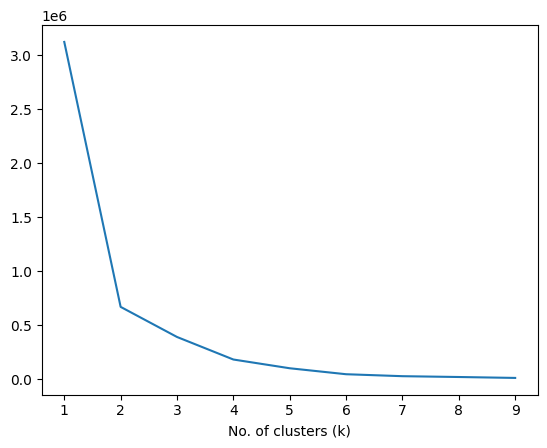

In [12]:
rfm.find_k(score_df,"monetary")

- We proceed with k = 3

In [13]:
# Assign the users into 3 clusters based on their monetary score
kmeans = KMeans(n_clusters=3).fit(score_df[["monetary"]])
score_df["monetary_cluster"] = kmeans.predict(score_df[["monetary"]])
score_df = rfm.reorder_cluster(score_df,"monetary_cluster","monetary",True) # ascending = True to make cluster 0 the worse
score_df.groupby(by="monetary_cluster")["monetary"].describe()

,count,mean,std,min,25%,50%,75%,max
monetary_cluster,,,,,,,,
0,4601.0,50.354053,4.409088,45.0,49.0,49.0,49.0,59.0
1,1168.0,79.955479,4.007457,75.0,79.0,79.0,79.0,91.0
2,1032.0,103.397287,15.975524,95.0,95.0,95.0,109.0,237.0


## Distributions

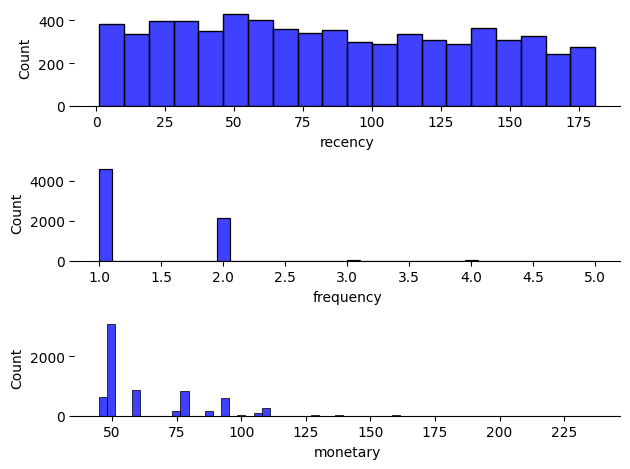

In [14]:
import seaborn as sns
f,ax = plt.subplots(3)

sns.despine(left=True)

sns.histplot(score_df.recency,color="b",ax=ax[0])
sns.histplot(score_df.frequency,color="b",ax=ax[1])
sns.histplot(score_df.monetary,color="b",ax=ax[2])

plt.tight_layout()

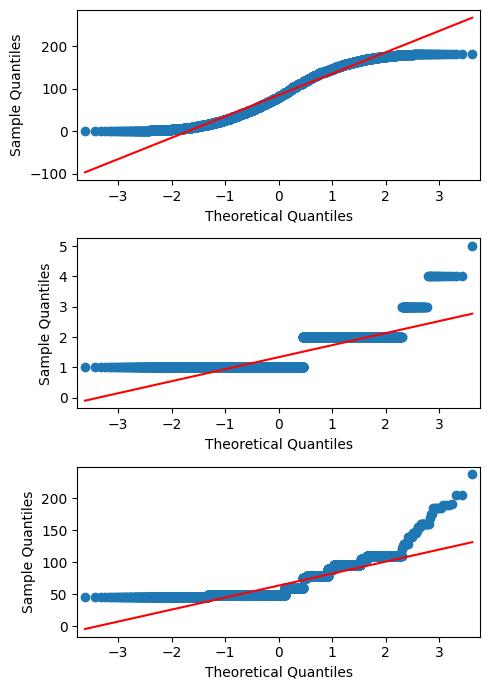

In [15]:
from statsmodels.graphics.gofplots import qqplot
f,ax = plt.subplots(3,1,figsize=(5,7))

qqplot(score_df["recency"],line="r",ax=ax[0],label="recency")
qqplot(score_df.frequency,line="r",ax=ax[1],label="frequency")
qqplot(score_df.monetary,line="r",ax=ax[2],label="monetary")


plt.tight_layout()

## Overall RFM score

In [16]:
score_df["rfm"] = score_df["recency_cluster"] + score_df["frequency_cluster"] + score_df["monetary_cluster"]
score_df.groupby("rfm")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
rfm,,,
1,154.139232,1.091221,53.899863
2,114.866101,1.346832,63.480732
3,70.035859,1.368421,63.636206
4,28.466592,1.372263,64.467715
5,23.132450,2.079470,103.158940


- From this, we segment them into Low/Medium/High value segments based on their rfm score
  - Low: 1 - 2
  - Medium: 3 - 4
  - High: 5

In [17]:
# Put them into Low/Medium/High value segments based on the overall rfm score
score_df["segment"] = "low"
score_df.loc[score_df["rfm"]>2,"segment"] = "medium"
score_df.loc[score_df["rfm"]>4,"segment"] = "high"
score_df

,user_id,recency,recency_cluster,frequency,frequency_cluster,monetary,monetary_cluster,rfm,segment
0,117878,174,0,1,1,49,0,1,low
1,118185,177,0,1,1,49,0,1,low
2,118933,180,0,1,1,49,0,1,low
3,119151,176,0,1,1,49,0,1,low
4,119790,174,0,1,1,49,0,1,low
...,...,...,...,...,...,...,...,...,...
6796,234941,1,3,2,0,95,2,5,high
6797,234943,1,3,2,0,75,1,4,medium
6798,234961,1,3,1,1,45,0,4,medium
6799,234967,1,3,1,1,49,0,4,medium


In [18]:
segment_order = ["low","medium","high"]
score_df["segment"] = pd.Categorical(score_df["segment"], categories=segment_order, ordered=True)
score_df.groupby("segment")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
segment,,,
low,134.023085,1.222148,58.807293
medium,48.943305,1.370370,64.058120
high,23.132450,2.079470,103.158940


## Target variable

In [51]:
target_df = ltv_df[(merged_df['date'] >= "2014-01-07") & (ltv_df['date'] <= "2014-12-31")]
target_df["profit_usd"] = target_df["price_usd"] - target_df["cogs_usd"]
target_6m = target_df.groupby("user_id")[["profit_usd"]].sum().reset_index()
target_6m.columns = ["user_id","6m_profit"]
target_6m

/var/folders/rc/s2_95tz949s0vjwhs4qv05_w0000gn/T/ipykernel_98350/404037078.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_df = ltv_df[(merged_df['date'] >= "2014-01-07") & (ltv_df['date'] <= "2014-12-31")]


,user_id,6m_profit
0,117878,30.5
1,119790,30.5
2,120043,30.5
3,120074,30.5
4,120478,37.5
...,...,...
16393,344183,20.5
16394,344185,31.5
16395,344194,30.5
16396,344260,30.5


In [ ]:
# Split the 6-month LTV into 3 cluters, which represent low-medium-high
kmeans = KMeans(n_clusters=3)
target_6m['ltv_cluster'] = kmeans.fit_predict(target_6m[['6m_profit']])
target_6m = rfm.reorder_cluster(target_6m,"ltv_cluter","6m_profit",True)
target_6m.groupby("ltv_cluster").mean()

,user_id,6m_profit
ltv_cluter,,
0,246538.793996,31.728873
1,254755.009849,52.092336
2,247461.345224,66.595125


<Axes: xlabel='ltv_cluter'>

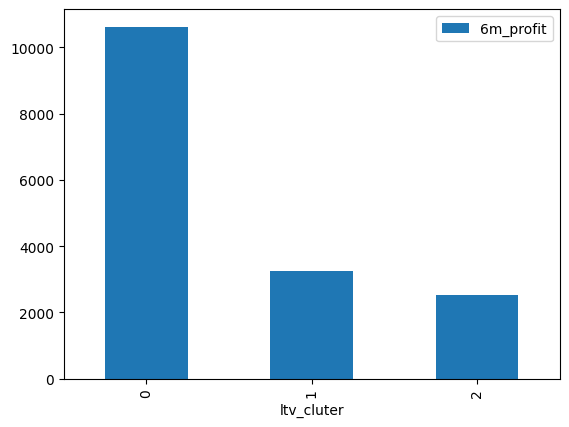

In [99]:
target_6m.groupby("ltv_cluter")[["6m_profit"]].count().plot.bar()

In [57]:
full_df = pd.merge(score_df,target_6m,on="user_id",how="left")
full_df = full_df.fillna(0)
full_df

,user_id,recency,recency_cluster,frequency,frequency_cluster,monetary,monetary_cluster,rfm,segment,6m_profit,ltv_cluter
0,117878,174,0,1,1,49,0,1,low,30.5,0.0
1,118185,177,0,1,1,49,0,1,low,0.0,0.0
2,118933,180,0,1,1,49,0,1,low,0.0,0.0
3,119151,176,0,1,1,49,0,1,low,0.0,0.0
4,119790,174,0,1,1,49,0,1,low,30.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6796,234941,1,3,2,0,95,2,5,high,62.0,2.0
6797,234943,1,3,2,0,75,1,4,medium,52.0,1.0
6798,234961,1,3,1,1,45,0,4,medium,31.5,0.0
6799,234967,1,3,1,1,49,0,4,medium,30.5,0.0


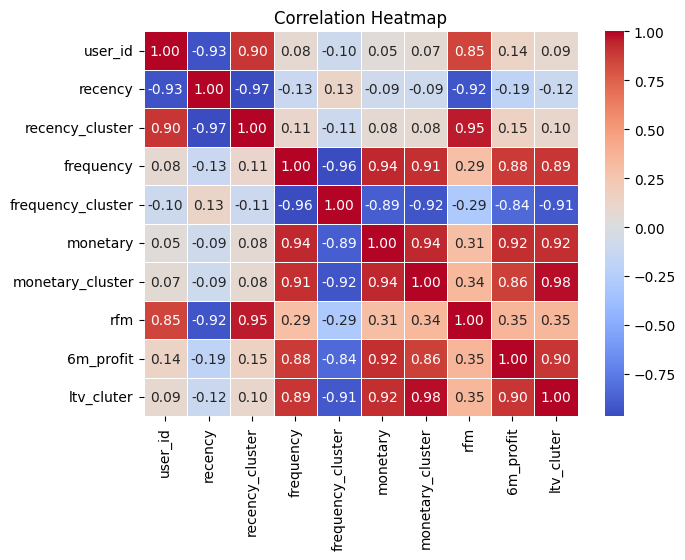

In [58]:
num_full_df = full_df.drop("segment",axis=1)
matrix = num_full_df.corr()

plt.figure(figsize=(7,5))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

- The correlation matrix shows strong correlations between 6-month profit/LTV (cluster) with frequency (cluster) and monetary (cluster)

In [ ]:
matrix['ltv_cluster'].sort_values(ascending=False)

ltv_cluter           1.000000
monetary_cluster     0.979709
monetary             0.920323
6m_profit            0.899596
frequency            0.894824
rfm                  0.351286
recency_cluster      0.103525
user_id              0.086103
recency             -0.117099
frequency_cluster   -0.909405
Name: ltv_cluter, dtype: float64

## Feature Engineering

In [59]:
# Use Label Encoding to encode categorical variable
# Label Enconding is a better option when the variable has meaningful hiarchy
le = LabelEncoder()
full_df['segment_encoded'] = le.fit_transform(full_df['segment'])
full_df = full_df.drop("segment",axis=1)
full_df

,user_id,recency,recency_cluster,frequency,frequency_cluster,monetary,monetary_cluster,rfm,6m_profit,ltv_cluter,segment_encoded
0,117878,174,0,1,1,49,0,1,30.5,0.0,1
1,118185,177,0,1,1,49,0,1,0.0,0.0,1
2,118933,180,0,1,1,49,0,1,0.0,0.0,1
3,119151,176,0,1,1,49,0,1,0.0,0.0,1
4,119790,174,0,1,1,49,0,1,30.5,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
6796,234941,1,3,2,0,95,2,5,62.0,2.0,0
6797,234943,1,3,2,0,75,1,4,52.0,1.0,2
6798,234961,1,3,1,1,45,0,4,31.5,0.0,2
6799,234967,1,3,1,1,49,0,4,30.5,0.0,2


## Splitting

In [182]:
temp_df = full_df.drop(["recency_cluster","frequency_cluster","monetary_cluster"],axis=1)
temp_df

,user_id,recency,frequency,monetary,rfm,6m_profit,ltv_cluter,segment_encoded
0,117878,174,1,49,1,30.5,0.0,1
1,118185,177,1,49,1,0.0,0.0,1
2,118933,180,1,49,1,0.0,0.0,1
3,119151,176,1,49,1,0.0,0.0,1
4,119790,174,1,49,1,30.5,0.0,1
...,...,...,...,...,...,...,...,...
6796,234941,1,2,95,5,62.0,2.0,0
6797,234943,1,2,75,4,52.0,1.0,2
6798,234961,1,1,45,4,31.5,0.0,2
6799,234967,1,1,49,4,30.5,0.0,2


# Prediction Model

In [183]:
from sklearn.model_selection import train_test_split


X = temp_df.drop(["ltv_cluter","6m_profit"],axis=1)
y = temp_df["ltv_cluter"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42)


In [184]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

models = []
results = []

models.append(("xgb",xgb.XGBClassifier(objective="multi:softprob")))
models.append(("dt",DecisionTreeClassifier()))
models.append(("knn",KNeighborsClassifier(5)))
models.append(("rf",RandomForestClassifier()))
models.append(("svc",SVC(gamma="scale")))


In [185]:
from sklearn import model_selection
from sklearn.model_selection import KFold


k = 5
random_seed = 45
for name,model in models:
    kfold = KFold(n_splits=k,random_state=random_seed,shuffle=True)
    cv_results = model_selection.cross_val_score(model,X_train,y_train,cv=kfold,scoring="f1_macro")
    results.append(cv_results)
    print(f"{name}: {cv_results.mean():.4f}")

xgb: 0.9895
dt: 0.9834
knn: 0.3806
rf: 0.9881
svc: 0.2691


- KNN and SVC show relatively lower performance due to the fact that our data is not scaled and these algorithms work on the premise of calculating distances between datapoints
- The rest of the models perform extremely well, given that it is a simple prediction task

In [186]:
# We proceed with XGBoost to predict the test set
from sklearn.metrics import accuracy_score


xgb_model = xgb.XGBClassifier(objective="multi:softprob").fit(X_train,y_train)
y_pred = xgb_model.predict(X_test)
test_acc = accuracy_score(y_test,y_pred)
print(f"Accuracy on test set: {test_acc:.4f}")


Accuracy on test set: 0.9971


In [187]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       229
         1.0       1.00      1.00      1.00        56
         2.0       1.00      0.98      0.99        56

    accuracy                           1.00       341
   macro avg       1.00      0.99      1.00       341
weighted avg       1.00      1.00      1.00       341



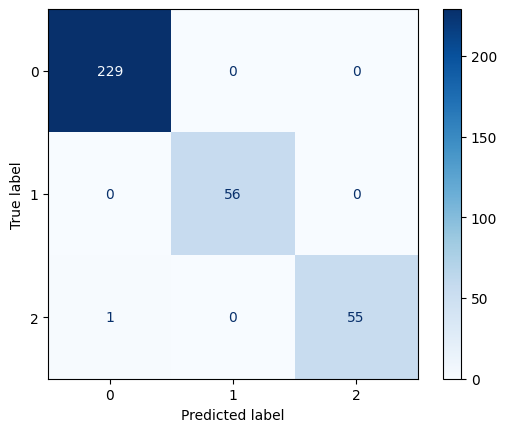

In [189]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap='Blues')
plt.show()